# **ワインデータセットを用いた機械学習入門**

## 概要

ポルトガルワインのデータセットを使ってより高度な機械学習手法を実習します。

> 1. **一般化線形モデル (GLM)** — *ポアソン回帰による品質スコアの予測*
> 2. **XGBoost(勾配ブースティング)** — *品質の予測と特徴量重要度の可視化*
> 3. **階層的クラスタリング** — *ラベルなしで赤ワインと白ワインを識別*

## データセットについて

ポルトガルの「Vinho Verde」ワインについて、赤ワイン約1,600本・白ワイン約4,900本の以下の情報が記録されています。

### 変数一覧
| 列名 | 意味 |
| --- | --- |
| `fixed acidity` | 不揮発性酸度 |
| `volatile acidity` | 揮発性酸度(高いと酢っぽくなる) |
| `citric acid` | クエン酸 |
| `residual sugar` | 残糖 |
| `chlorides` | 塩化物 |
| `free sulfur dioxide` | 遊離亜硫酸 |
| `total sulfur dioxide` | 総亜硫酸 |
| `density` | 密度 |
| `pH` | pH |
| `sulphates` | 硫酸塩 |
| `alcohol` | アルコール度数 |
| `quality` | 品質スコア(0〜10の整数、官能評価) |

### Citation
- Aeberhard S and Forina M (1992) Wine. UCI Machine Learning Repository. https://doi.org/10.24432/C5PC7J.
- Aeberhard S, Coomans D, de Vel O (1994) **Comparative analysis of statistical pattern recognition methods in high dimensional settings**,
*Pattern Recognition*, 27(8):1065-1077

## 0. 必要ライブラリのインストール(初回のみ)

In [100]:
# 初回のみ実行してください
!pip install scikit-learn seaborn matplotlib pandas scipy statsmodels matplotlib-fontja xgboost

## 1. データの取得と確認

UCI のサーバから直接 CSV を読み込みます。赤ワインと白ワインの2ファイルを取得し、`color` 列を付けて結合します。

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys

# ---- 日本語フォントの設定(文字化け対策) ----
# 順序が重要:seaborn のテーマを「先に」設定すると rcParams を初期化するので、
# その「あと」で matplotlib-fontja を import すれば font.family が上書きされない。
sns.set_style("whitegrid")
print("kernel python :", sys.executable)
try:
    import matplotlib_fontja  # noqa: F401
    # 念のため font.sans-serif の先頭にも IPAexGothic を入れておく
    # (将来 sns.set_theme() などで font.family が 'sans-serif' に戻されても CJK が出るように)
    _sans = [f for f in plt.rcParams["font.sans-serif"] if f != "IPAexGothic"]
    plt.rcParams["font.sans-serif"] = ["IPAexGothic"] + _sans
    print("matplotlib-fontja: OK")
except ImportError as e:
    print(f"matplotlib-fontja import 失敗: {e}")
    print("→ 上のセル(%pip install ...)を先に実行してください。")
    from matplotlib import font_manager
    _candidates = [
        "IPAexGothic", "IPAGothic", "Noto Sans CJK JP", "Noto Sans JP",
        "TakaoGothic", "VL Gothic", "Hiragino Sans", "Yu Gothic", "Meiryo",
    ]
    _available = {f.name for f in font_manager.fontManager.ttflist}
    _picked = next((n for n in _candidates if n in _available), None)
    if _picked:
        plt.rcParams["font.family"] = _picked
        plt.rcParams["font.sans-serif"] = [_picked] + plt.rcParams["font.sans-serif"]
        print(f"フォールバックで {_picked!r} を使用します。")
    else:
        print("利用可能な CJK フォントが見つかりません。")
plt.rcParams["axes.unicode_minus"] = False
print("font.family    :", plt.rcParams["font.family"])
print("font.sans-serif:", plt.rcParams["font.sans-serif"][:3], "...")


URL_RED = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
URL_WHITE = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

red = pd.read_csv(URL_RED, sep=";")
white = pd.read_csv(URL_WHITE, sep=";")

# 色のラベルを付与して結合
red["color"] = "red"
white["color"] = "white"
df = pd.concat([red, white], ignore_index=True)

print(f"赤ワイン: {len(red)} 本")
print(f"白ワイン: {len(white)} 本")
print(f"合計    : {len(df)} 本")
df.head()

kernel python : /home/qm/claude/lecture/ml/phylo_work/.venv/bin/python
matplotlib-fontja: OK
font.family    : ['sans-serif']
font.sans-serif: ['IPAexGothic', 'Arial', 'DejaVu Sans'] ...
赤ワイン: 1599 本
白ワイン: 4898 本
合計    : 6497 本


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [102]:
# 列名にスペースが含まれていると扱いにくいので、アンダースコアに置換
df.columns = df.columns.str.replace(" ", "_")
print("カラム名:", df.columns.tolist())

カラム名: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'color']


In [103]:
# 各列の型と欠損数
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [104]:
# 基本統計量
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [105]:
# 品質スコアの分布
print("品質スコアの分布:")
print(df["quality"].value_counts().sort_index())

品質スコアの分布:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


## 2. 探索的データ解析(EDA)

まずは品質スコアの分布と、特徴量との関係を可視化します。

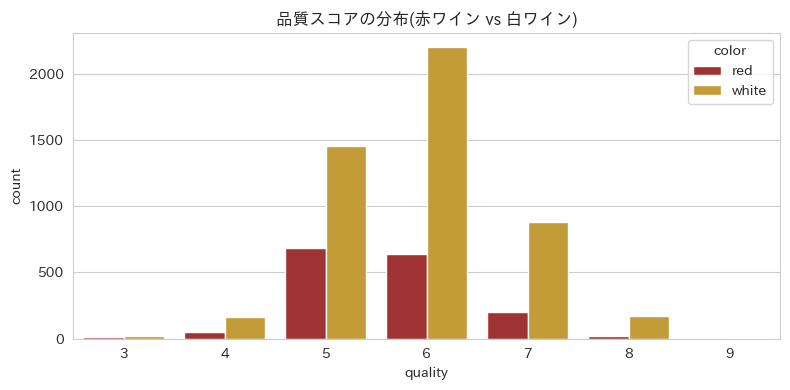

In [106]:
# 品質スコアのヒストグラム(赤白別)
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x="quality", hue="color",
              palette={"red": "#b22222", "white": "#daa520"}, ax=ax)
ax.set_title("品質スコアの分布(赤ワイン vs 白ワイン)")
plt.tight_layout()
plt.show()

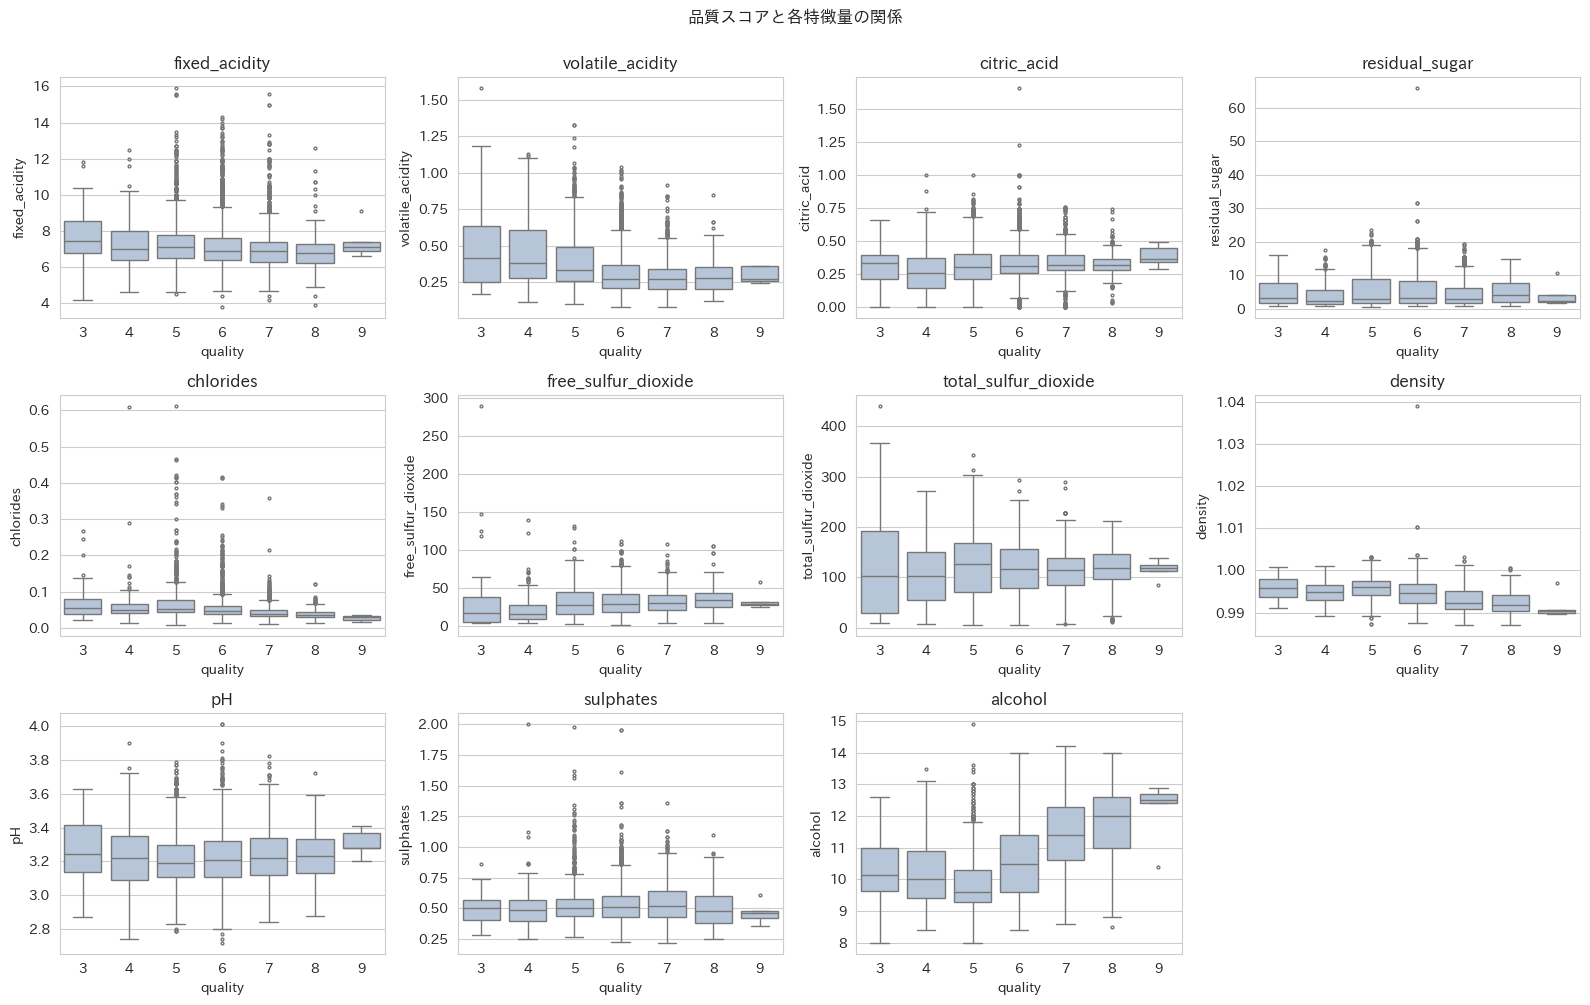

In [107]:
# 品質と各特徴量の関係を箱ひげ図で
features = [c for c in df.columns if c not in ["quality", "color"]]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=df, x="quality", y=feat, ax=ax,
                color="lightsteelblue", fliersize=2)
    ax.set_title(feat)
# 余ったサブプロットを非表示に
for ax in axes.flat[len(features):]:
    ax.set_visible(False)
plt.suptitle("品質スコアと各特徴量の関係", y=1.00)
plt.tight_layout()
plt.show()

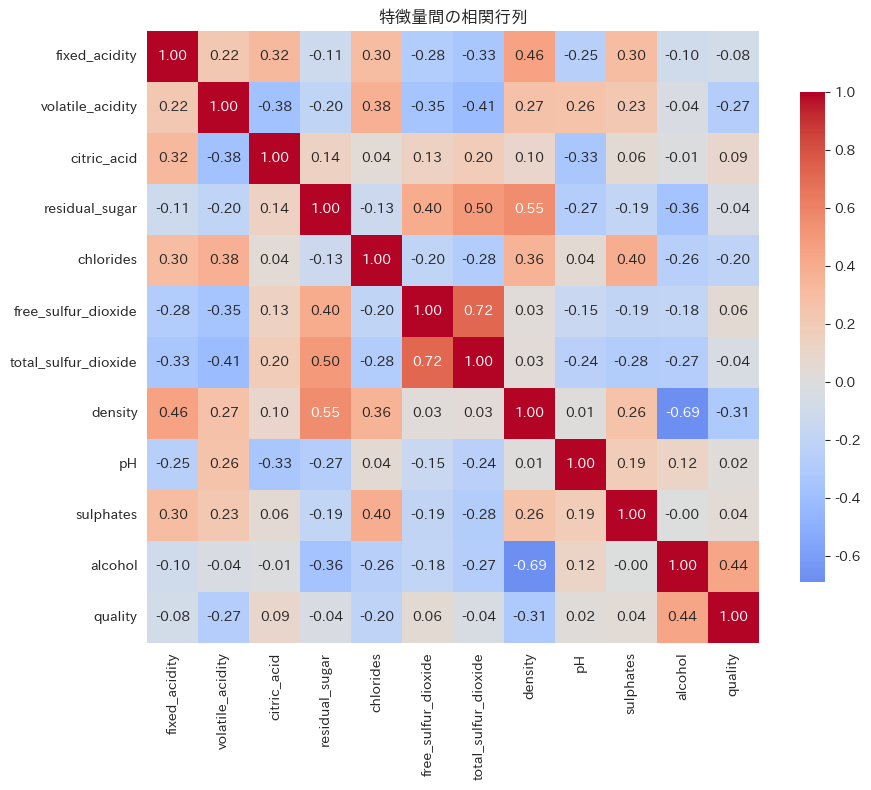

In [108]:
# 相関行列のヒートマップ
plt.figure(figsize=(10, 8))
corr = df[features + ["quality"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("特徴量間の相関行列")
plt.tight_layout()
plt.show()

**観察ポイント**
- アルコール度数と品質に正の相関がある(箱ひげ図でも右肩上がり)
- 揮発性酸度と品質には負の相関がある(高いと「酢っぽい」のでマイナス評価)
- `density` は `alcohol` や `residual_sugar` と強く相関しており、多重共線性に注意

## 3. 一般化線形モデル(ポアソン回帰)で品質を予測

品質スコアは 0〜10 の整数値(計数データ)なので、ポアソン回帰が自然な選択です。`statsmodels` を使うと係数の p 値や信頼区間が見えるので、教育用途に向いています。

In [109]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = df[features].copy()
y = df["quality"].copy()

# 標準化(係数の大小比較がしやすくなる)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

# 訓練・テスト分割
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# ポアソン回帰(GLM: family=Poisson, link=log)
X_train_sm = sm.add_constant(X_train)
glm = sm.GLM(y_train, X_train_sm, family=sm.families.Poisson())
result = glm.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                quality   No. Observations:                 4547
Model:                            GLM   Df Residuals:                     4535
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8435.6
Date:                Thu, 28 May 2026   Deviance:                       425.39
Time:                        16:29:41   Pearson chi2:                     422.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.03925
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.7577 

In [110]:
# テストデータでの予測
X_test_sm = sm.add_constant(X_test)
y_pred = result.predict(X_test_sm)

print(f"MAE  (平均絶対誤差): {mean_absolute_error(y_test, y_pred):.3f}")
print(f"RMSE (二乗平均平方根誤差): {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

MAE  (平均絶対誤差): 0.564
RMSE (二乗平均平方根誤差): 0.730


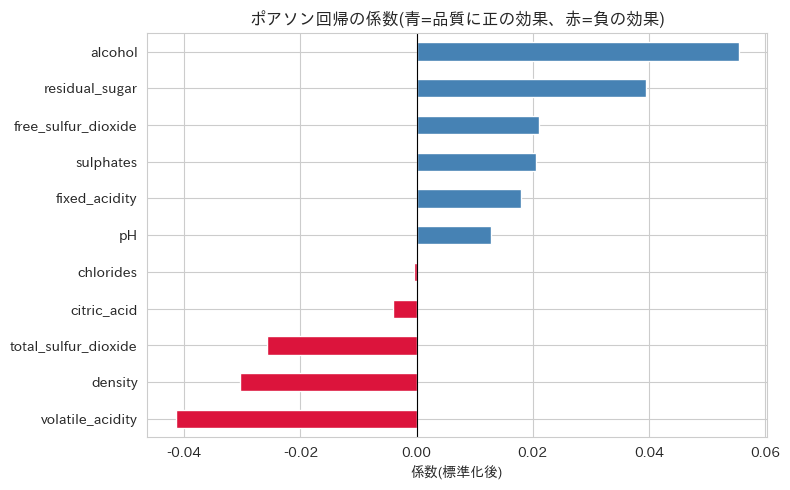

In [111]:
# 係数の可視化(標準化済みなので大小比較が可能)
coefs = result.params.drop("const").sort_values()

plt.figure(figsize=(8, 5))
colors = ["crimson" if v < 0 else "steelblue" for v in coefs]
coefs.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("係数(標準化後)")
plt.title("ポアソン回帰の係数(青=品質に正の効果、赤=負の効果)")
plt.tight_layout()
plt.show()

**学生への質問**
- 品質を高めるのに最も効く特徴量は何ですか?
- 揮発性酸度(volatile_acidity)の係数の符号は、ワインの常識的な評価と整合していますか?
- p 値の大きい(有意でない)変数はどれですか? それは何を意味する?

## 4. 正則化線形回帰(Ridge / Lasso)で多重共線性に対処

第3章の GLM では、`density` や `alcohol` の係数が大きくぶれることが知られています。
これは特徴量同士が強く相関している(**多重共線性**)せいで、係数の推定が不安定になるからです。

**正則化**は、係数の大きさそのものに罰則を加えることでこの不安定さを抑える手法です。

- **Ridge (L2 正則化)**: 係数の二乗和に罰則 → 大きな係数を全体的に縮める
- **Lasso (L1 正則化)**: 係数の絶対値の和に罰則 → 一部の係数を**ちょうどゼロ**にして変数選択を行う

ここでは scikit-learn の `RidgeCV` / `LassoCV` を使い、**交差検証で罰則の強さ `alpha` を自動選択**します。
(なお scikit-learn の Ridge/Lasso はガウス回帰(最小二乗)なので、第3章のポアソン回帰とは厳密には別物です。係数の方向性の比較を主眼とします。)

In [112]:
from sklearn.linear_model import RidgeCV, LassoCV, lasso_path

# 第3章と同じ訓練・テスト分割(標準化済み X_scaled, y を再利用)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

alphas = np.logspace(-3, 2, 50)

ridge = RidgeCV(alphas=alphas, cv=5).fit(X_train, y_train)
lasso = LassoCV(alphas=alphas, cv=5, max_iter=20000, random_state=42).fit(X_train, y_train)

print(f"Ridge: 選ばれた alpha = {ridge.alpha_:.4f}")
print(f"Lasso: 選ばれた alpha = {lasso.alpha_:.4f}")
print(f"Lasso でゼロになった係数の数: {(lasso.coef_ == 0).sum()} / {len(features)}")

y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

print()
print(f"Ridge  MAE: {mean_absolute_error(y_test, y_pred_ridge):.3f}, "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.3f}")
print(f"Lasso  MAE: {mean_absolute_error(y_test, y_pred_lasso):.3f}, "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.3f}")

Ridge: 選ばれた alpha = 15.2642
Lasso: 選ばれた alpha = 0.0010
Lasso でゼロになった係数の数: 0 / 11

Ridge  MAE: 0.564, RMSE: 0.729
Lasso  MAE: 0.564, RMSE: 0.729


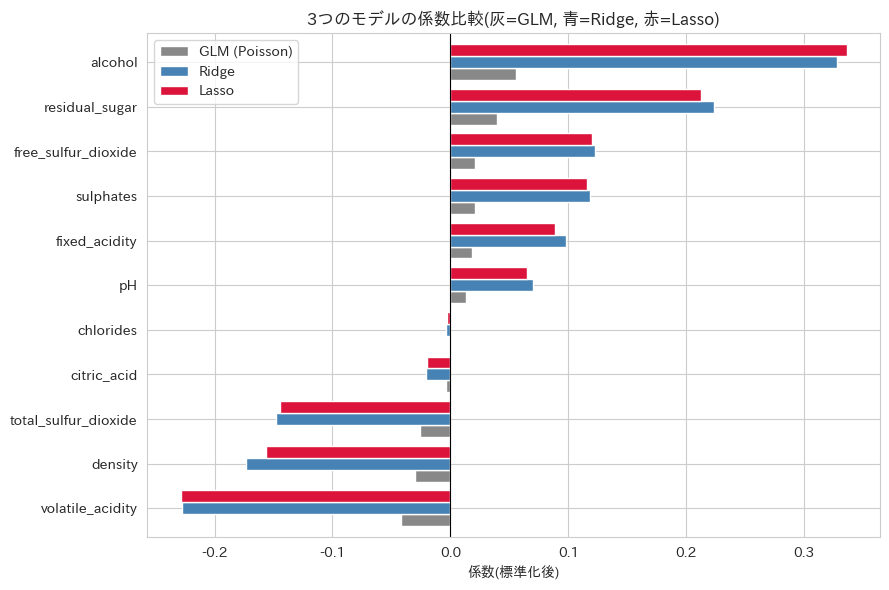

Lasso でゼロに縮んだ変数:
(なし)


In [113]:
# 係数の比較:GLM (Poisson, 正則化なし) vs Ridge vs Lasso
coef_df = pd.DataFrame({
    "GLM (Poisson)": result.params.drop("const"),
    "Ridge":          pd.Series(ridge.coef_, index=features),
    "Lasso":          pd.Series(lasso.coef_, index=features),
})
# GLM の係数順に並べる(視覚的にわかりやすく)
coef_df = coef_df.loc[coef_df["GLM (Poisson)"].sort_values().index]

ax = coef_df.plot(
    kind="barh", figsize=(9, 6),
    color=["#888888", "steelblue", "crimson"],
    width=0.8,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("係数(標準化後)")
ax.set_title("3つのモデルの係数比較(灰=GLM, 青=Ridge, 赤=Lasso)")
plt.tight_layout()
plt.show()

print("Lasso でゼロに縮んだ変数:")
zero_vars = coef_df.index[coef_df["Lasso"] == 0].tolist()
print(zero_vars if zero_vars else "(なし)")

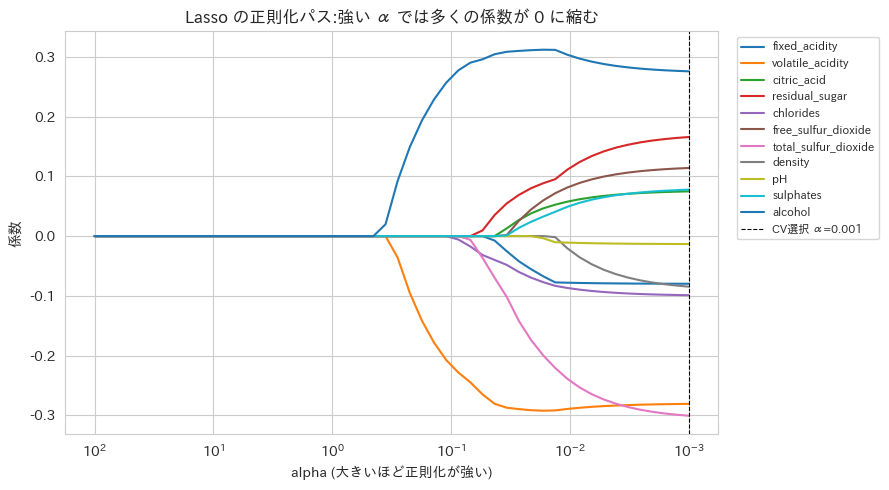

In [114]:
# Lasso の正則化パス:alpha を変えていくと各係数がどう動くか
alphas_path, coefs_path, _ = lasso_path(
    X_train.values, y_train.values, alphas=alphas
)

plt.figure(figsize=(9, 5))
for i, feat in enumerate(features):
    plt.plot(alphas_path, coefs_path[i], label=feat)
plt.xscale("log")
plt.axvline(lasso.alpha_, color="black", linestyle="--", linewidth=0.8,
            label=f"CV選択 α={lasso.alpha_:.3f}")
plt.gca().invert_xaxis()   # 左から右に正則化が強くなる方向に
plt.xlabel("alpha (大きいほど正則化が強い)")
plt.ylabel("係数")
plt.title("Lasso の正則化パス:強い α では多くの係数が 0 に縮む")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [115]:
# 4モデルの精度比較表(GLM, Ridge, Lasso, あとで RF も追加されます)
comparison_reg = pd.DataFrame({
    "モデル": ["GLM (Poisson)", "Ridge", "Lasso"],
    "MAE":  [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    ],
})
print(comparison_reg.to_string(index=False))

          モデル      MAE     RMSE
GLM (Poisson) 0.564312 0.730443
        Ridge 0.563814 0.729477
        Lasso 0.563904 0.729332


**学生への質問**
- Ridge と Lasso では、`density` のように他の変数と強く相関している係数はどう変化しましたか?
- Lasso でゼロになった変数は、第3章 GLM で p 値が大きかった(=有意でなかった)変数と一致していますか?
- 正則化パスを見ると、`alpha` を大きくしていったとき、最後まで残る(=最も重要な)変数は何ですか?
- 予測精度(MAE/RMSE)は GLM とほぼ同じになるはずです。それでも正則化を使うメリットは何でしょうか?

## 5. XGBoost(勾配ブースティング)で品質を予測

ランダムフォレストと並んで表形式データで強力なのが**勾配ブースティング決定木**です。
弱い決定木を順番に積み重ね、前の木が誤った部分を次の木が補正するように学習します。
ここでは代表的な実装である **XGBoost** を使います。GLM との精度比較がポイントです。

In [116]:
from xgboost import XGBRegressor

X = df[features]
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(f"XGBoost")
print(f"  MAE : {mean_absolute_error(y_test, y_pred_xgb):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.3f}")

# GLM との比較表
comparison = pd.DataFrame({
    "モデル": ["GLM (Poisson)", "XGBoost"],
    "MAE":  [mean_absolute_error(y_test, y_pred), mean_absolute_error(y_test, y_pred_xgb)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred)), np.sqrt(mean_squared_error(y_test, y_pred_xgb))],
})
print("\nモデル比較:")
print(comparison.to_string(index=False))

XGBoost
  MAE : 0.462
  RMSE: 0.616

モデル比較:
          モデル      MAE     RMSE
GLM (Poisson) 0.564312 0.730443
      XGBoost 0.461656 0.615990


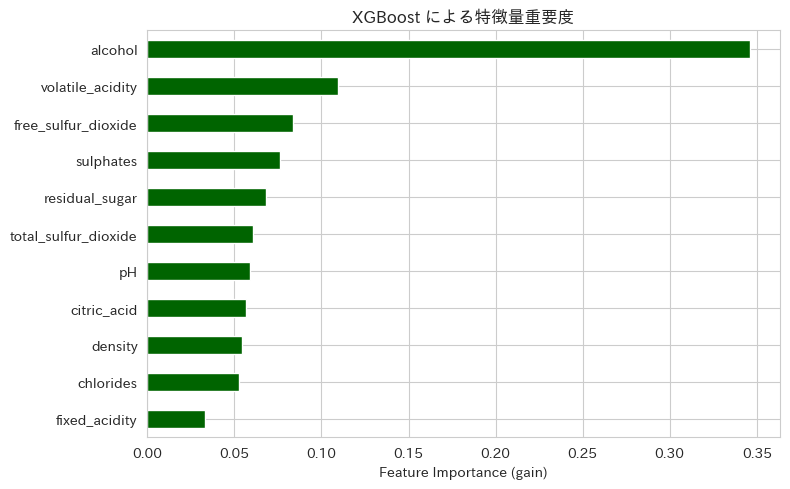

In [117]:
# 特徴量重要度の可視化(XGBoost の feature_importances_ はゲイン正規化)
importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 5))
importance.plot(kind="barh", color="darkgreen")
plt.xlabel("Feature Importance (gain)")
plt.title("XGBoost による特徴量重要度")
plt.tight_layout()
plt.show()

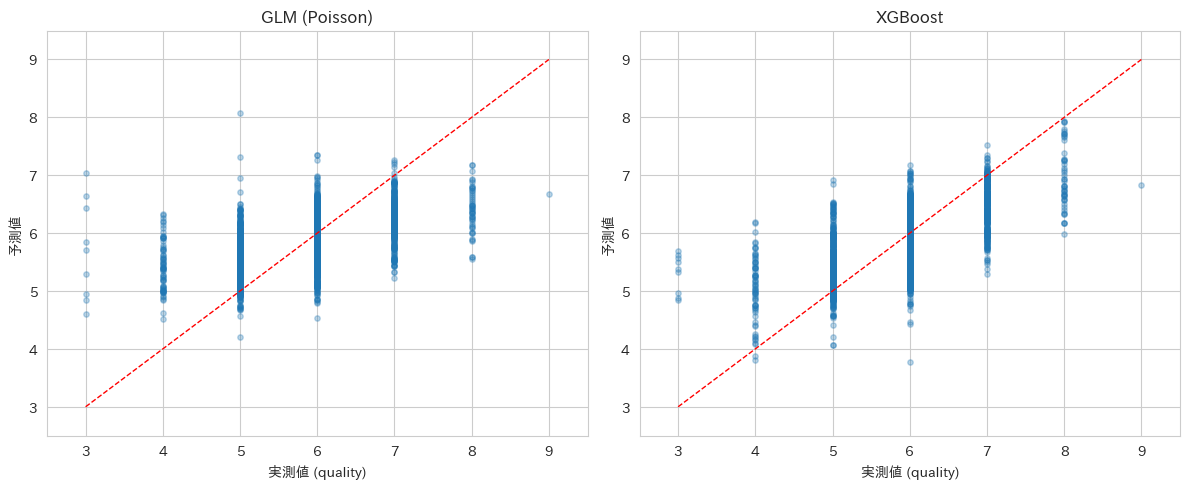

In [118]:
# 予測値 vs 実測値の散布図
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in [(axes[0], y_pred, "GLM (Poisson)"),
                         (axes[1], y_pred_xgb, "XGBoost")]:
    ax.scatter(y_test, pred, alpha=0.3, s=15)
    ax.plot([3, 9], [3, 9], "r--", linewidth=1)
    ax.set_xlabel("実測値 (quality)")
    ax.set_ylabel("予測値")
    ax.set_title(title)
    ax.set_xlim(2.5, 9.5)
    ax.set_ylim(2.5, 9.5)

plt.tight_layout()
plt.show()

**学生への質問**
- GLM と XGBoost では、どちらが精度が高い? その差はどれくらい?
- GLM の係数と XGBoost の特徴量重要度は、上位の変数が一致している? 違うとしたらなぜ?
- 予測値 vs 実測値のプロットを見ると、両モデルとも極端な値(3 や 8、9)の予測が苦手な様子が見える。なぜか?

## 6. 簡単なニューラルネットワーク(MLP)で品質を予測

最後に、もう一つの非線形モデルとして **多層パーセプトロン(MLP, Multi-Layer Perceptron)** を試します。
XGBoost とは別の角度で非線形な関係を捉えられるモデルで、深層学習の最も基本的な形でもあります。

scikit-learn の `MLPRegressor` を使えば、Ridge や XGBoost と同じ `fit`/`predict` 形式で扱えます。

**注意点**
- ニューラルネットワークは入力スケールに敏感なので、**標準化した特徴量(`X_scaled`)を使うことが必須**です。
- 重みはランダム初期化なので、`random_state` を固定しないと結果が再現できません。
- 隠れ層のサイズや学習率はハイパーパラメータです。ここでは中規模の `(32, 16)` の2層構成を使います。

In [119]:
from sklearn.neural_network import MLPRegressor

# 標準化済み特徴量で再分割(GLM/Ridge と同じ random_state=42 の分割)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

mlp = MLPRegressor(
    hidden_layer_sizes=(32, 16),   # 隠れ層2層: 32ユニット → 16ユニット
    activation="relu",
    solver="adam",
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,           # 検証損失が改善しなくなったら停止
    validation_fraction=0.1,
    random_state=42,
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print(f"学習が止まった epoch 数: {mlp.n_iter_}")
print(f"MLP  MAE : {mean_absolute_error(y_test, y_pred_mlp):.3f}")
print(f"MLP  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_mlp)):.3f}")

学習が止まった epoch 数: 96
MLP  MAE : 0.547
MLP  RMSE: 0.706


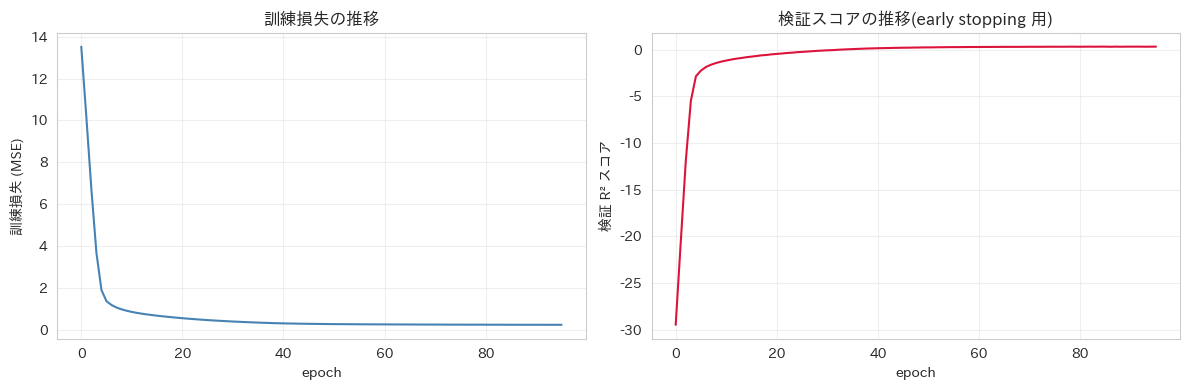

In [120]:
# 学習曲線:訓練損失と検証スコアの推移
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mlp.loss_curve_, color="steelblue")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("訓練損失 (MSE)")
axes[0].set_title("訓練損失の推移")
axes[0].grid(alpha=0.3)

if hasattr(mlp, "validation_scores_") and mlp.validation_scores_:
    axes[1].plot(mlp.validation_scores_, color="crimson")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("検証 R² スコア")
    axes[1].set_title("検証スコアの推移(early stopping 用)")
    axes[1].grid(alpha=0.3)
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()

          モデル      MAE     RMSE
GLM (Poisson) 0.564312 0.730443
        Ridge 0.563814 0.729477
        Lasso 0.563904 0.729332
      XGBoost 0.461656 0.615990
     MLP (NN) 0.546761 0.705666


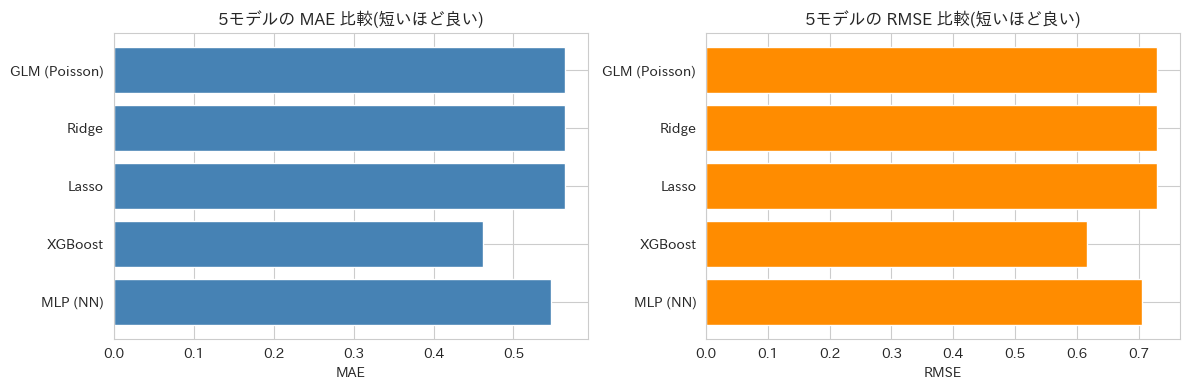

In [121]:
# 5モデルの精度比較表
comparison_all = pd.DataFrame({
    "モデル": ["GLM (Poisson)", "Ridge", "Lasso", "XGBoost", "MLP (NN)"],
    "MAE":  [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_mlp),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_mlp)),
    ],
})
print(comparison_all.to_string(index=False))

# 棒グラフでの可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, color in [(axes[0], "MAE", "steelblue"), (axes[1], "RMSE", "darkorange")]:
    ax.barh(comparison_all["モデル"], comparison_all[metric], color=color)
    ax.set_xlabel(metric)
    ax.set_title(f"5モデルの {metric} 比較(短いほど良い)")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

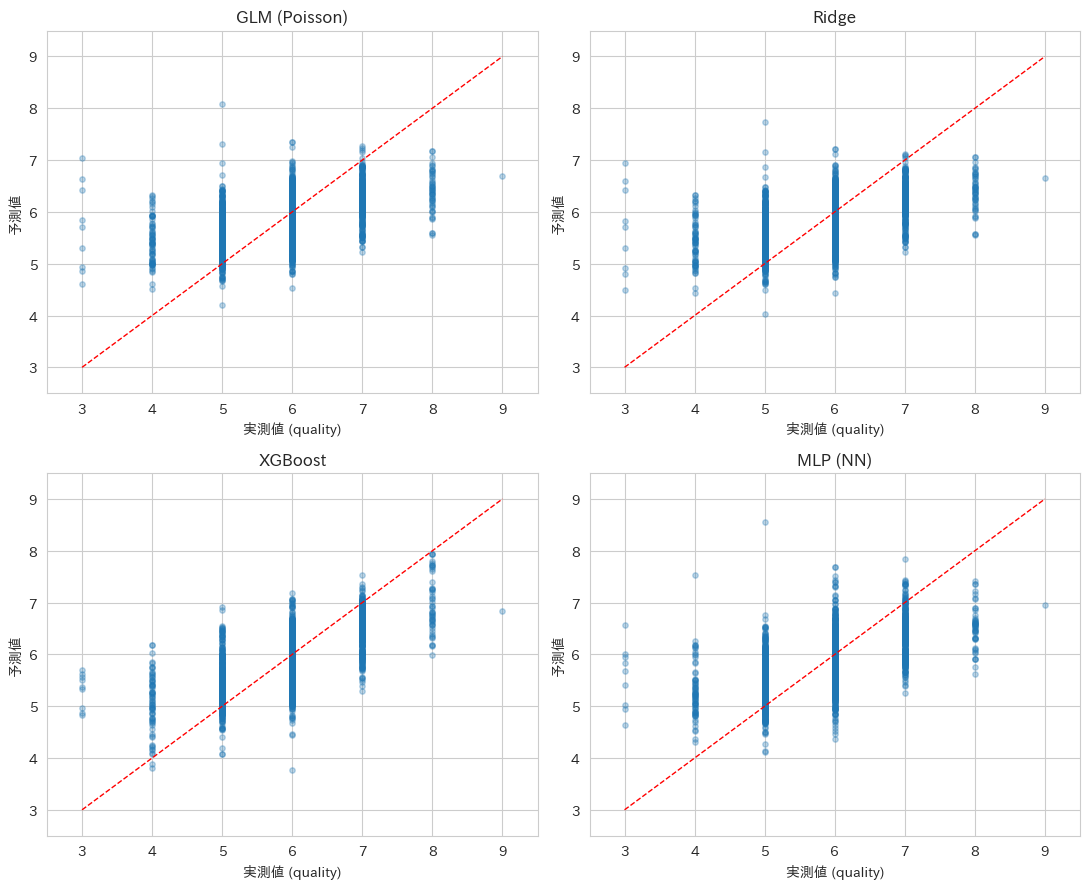

In [122]:
# 予測値 vs 実測値:MLP を含めた4モデルを並べる
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
panels = [
    (axes[0, 0], y_pred,       "GLM (Poisson)"),
    (axes[0, 1], y_pred_ridge, "Ridge"),
    (axes[1, 0], y_pred_xgb,   "XGBoost"),
    (axes[1, 1], y_pred_mlp,   "MLP (NN)"),
]
for ax, pred, title in panels:
    ax.scatter(y_test, pred, alpha=0.3, s=15)
    ax.plot([3, 9], [3, 9], "r--", linewidth=1)
    ax.set_xlabel("実測値 (quality)")
    ax.set_ylabel("予測値")
    ax.set_title(title)
    ax.set_xlim(2.5, 9.5)
    ax.set_ylim(2.5, 9.5)
plt.tight_layout()
plt.show()

**学生への質問**
- MLP の精度は GLM、Ridge/Lasso、XGBoost と比べてどうですか? なぜそうなったと思いますか?
- `hidden_layer_sizes` を `(64, 32, 16)` のように大きくすると精度はどう変化しますか? 過学習(訓練データには合うがテストデータでは精度が落ちる)が起きていませんか?
- 訓練損失のグラフを見て、もっと epoch 数を増やしたら精度が上がりそうですか? それとも early stopping が適切に働いていますか?
- なぜニューラルネットワークでは特徴量の **標準化が必須** なのに、XGBoost のような決定木ベースのモデルでは不要なのでしょうか?

**ニューラルネットワークの位置づけ**
このような小さな表形式データ(数千行 × 10数列)では、ニューラルネットワークが他のモデルを大きく上回ることは少なく、しばしば XGBoost や LightGBM などの勾配ブースティングモデルに負けます。NN の真価が出るのは、画像・音声・テキストなどの**大規模で構造化されていないデータ**です。

## 7. 階層的クラスタリング(教師なし学習)

色ラベル(red/white)を **一切使わず** に、化学成分だけから赤・白を区別できるかを試します。
デンドログラム単体ではなく、**各特徴量のヒートマップ**と組み合わせて描画することで、「どの特徴量パターンを持つサンプルが同じクラスタに集まったか」が一目でわかります。
ヒートマップ左側の細い色帯は答え合わせ用の色ラベルで、クラスタリングの計算には使っていません。

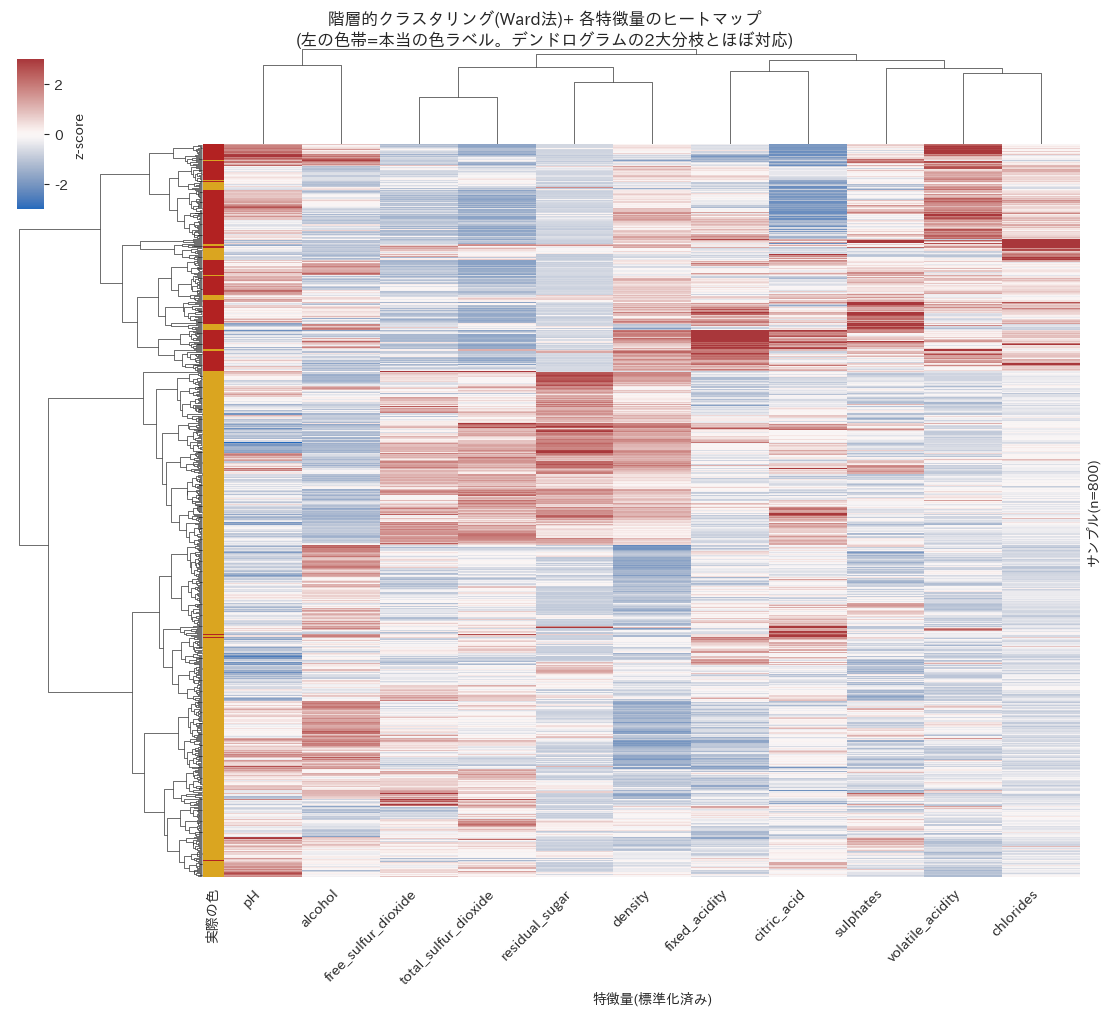

In [123]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 計算量を抑えるため、ランダムに800サンプル抽出してクラスタリング
sample = df.sample(n=800, random_state=42).reset_index(drop=True)

X_sample = sample[features]
X_scaled_sample = StandardScaler().fit_transform(X_sample)
X_scaled_df = pd.DataFrame(X_scaled_sample, columns=features, index=sample.index)

# Ward 法でリンケージを計算(後続セルでも fcluster に使う)
Z = linkage(X_scaled_sample, method="ward")

# 行注釈の細い色帯:本当の色ラベル(クラスタリングには使っていない、答え合わせ用)
row_colors = sample["color"].map({"red": "#b22222", "white": "#daa520"})
row_colors.name = "実際の色"

# clustermap = 行(サンプル)のデンドログラム + 列(特徴量)のデンドログラム
#              + 標準化済み特徴量のヒートマップ
g = sns.clustermap(
    X_scaled_df,
    row_linkage=Z,          # 上で計算した Ward 法のリンケージを使う
    col_cluster=True,       # 特徴量側もクラスタリング
    cmap="vlag", center=0, vmin=-3, vmax=3,
    row_colors=row_colors,
    figsize=(11, 10),
    xticklabels=True, yticklabels=False,
    dendrogram_ratio=(0.18, 0.12),
    colors_ratio=0.02,
    cbar_pos=(0.02, 0.82, 0.025, 0.15),
    cbar_kws={"label": "z-score"},
)
g.ax_heatmap.set_xlabel("特徴量(標準化済み)")
g.ax_heatmap.set_ylabel(f"サンプル(n={len(sample)})")
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right")
g.fig.suptitle(
    "階層的クラスタリング(Ward法)+ 各特徴量のヒートマップ\n"
    "(左の色帯=本当の色ラベル。デンドログラムの2大分枝とほぼ対応)",
    y=1.02, fontsize=12,
)
plt.show()

In [124]:
# 2クラスタに切り分け
clusters = fcluster(Z, t=2, criterion="maxclust")
sample["cluster"] = clusters

# 答え合わせ:実際の色ラベルとの対応
print("クラスタ vs 色(答え合わせ):")
print(pd.crosstab(sample["cluster"], sample["color"]))

# 一致率を計算
ct = pd.crosstab(sample["cluster"], sample["color"])
best_match = ct.values.max(axis=1).sum() / ct.values.sum()
print(f"\nクラスタを色に最適にマッチさせた場合の一致率: {best_match:.1%}")

クラスタ vs 色(答え合わせ):
color    red  white
cluster            
1        207     41
2          3    549

クラスタを色に最適にマッチさせた場合の一致率: 94.5%


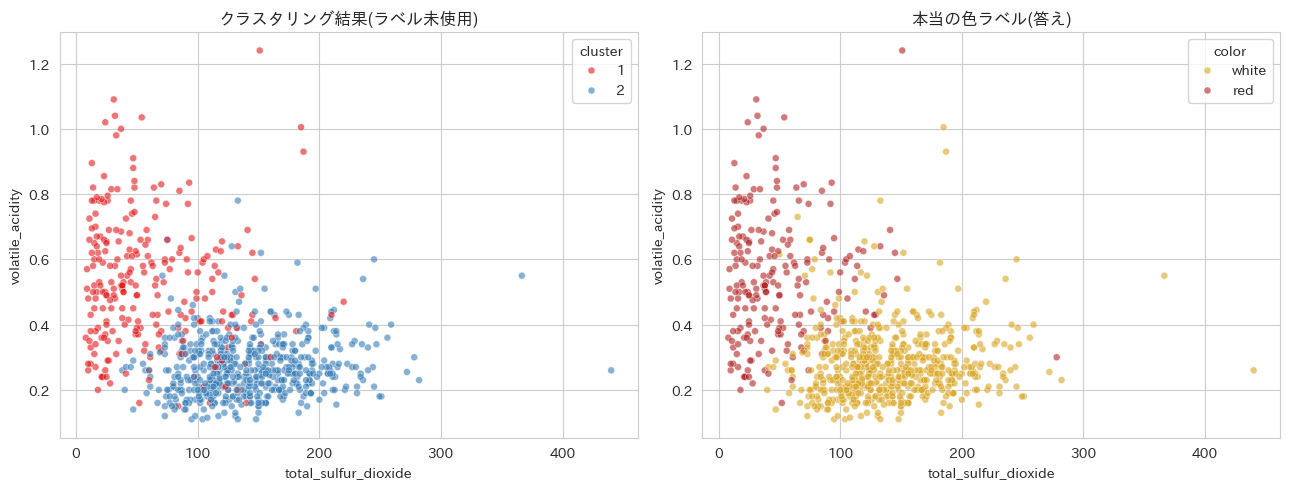

In [125]:
# 可視化:総亜硫酸 × 揮発性酸度 の平面で「クラスタ」と「本当の色」を比較
# (赤白を最もよく分ける2変数の組み合わせ)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=sample, x="total_sulfur_dioxide", y="volatile_acidity",
    hue="cluster", palette="Set1", ax=axes[0], alpha=0.6, s=25
)
axes[0].set_title("クラスタリング結果(ラベル未使用)")

sns.scatterplot(
    data=sample, x="total_sulfur_dioxide", y="volatile_acidity",
    hue="color", palette={"red": "#b22222", "white": "#daa520"},
    ax=axes[1], alpha=0.6, s=25
)
axes[1].set_title("本当の色ラベル(答え)")

plt.tight_layout()
plt.show()

**学生への気づきポイント**

色ラベルを一切使っていないのに、赤ワインと白ワインがほぼ正確に分かれることが実感できます。これは、赤と白で化学成分(特に総亜硫酸と揮発性酸度)が大きく異なるためです。実際の醸造プロセスの違いがデータに反映されていることがわかります。

## 8. 主成分分析(PCA)による次元削減

11個の化学成分(特徴量)を、情報量を保ったまま少数の主成分にまとめます。
上位3個の主成分を**3次元散布図**で表示すれば全体像が一望できるほか、**因子負荷量(loading)** を見ることで「各主成分は元のどの変数を強く反映しているか」を解釈できます。

> **Tip:** Jupyter で 3D 散布図をマウスで回転させたい場合は、セルの先頭に `%matplotlib widget`(要 `jupyter-matplotlib` パッケージ)を書くとインタラクティブモードになります。本ノートブックでは静止画(`%matplotlib inline`、デフォルト)のまま、`view_init` で固定視点を指定しています。

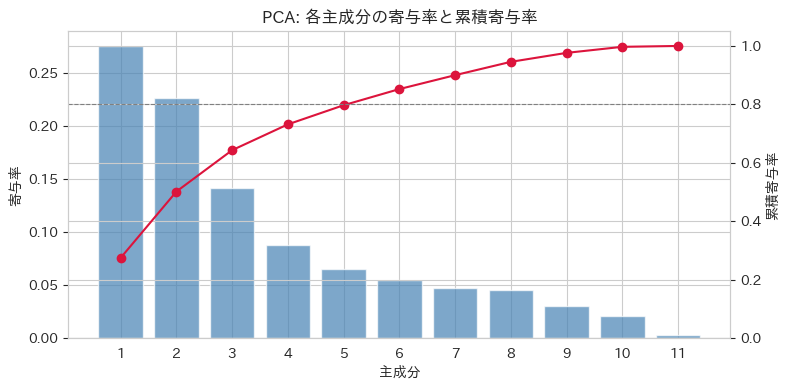

各主成分の寄与率:
  PC 1: 0.275  (累積 0.275)
  PC 2: 0.227  (累積 0.502)
  PC 3: 0.141  (累積 0.644)
  PC 4: 0.088  (累積 0.732)
  PC 5: 0.065  (累積 0.797)
  PC 6: 0.055  (累積 0.853)
  PC 7: 0.048  (累積 0.900)
  PC 8: 0.046  (累積 0.946)
  PC 9: 0.031  (累積 0.976)
  PC10: 0.021  (累積 0.997)
  PC11: 0.003  (累積 1.000)


In [126]:
from sklearn.decomposition import PCA

# PCA は標準化した特徴量に対して行うのが基本
X_all = df[features]
X_all_scaled = StandardScaler().fit_transform(X_all)

pca = PCA(n_components=len(features))
scores = pca.fit_transform(X_all_scaled)   # サンプル × 主成分

# 寄与率と累積寄与率
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

fig, ax1 = plt.subplots(figsize=(8, 4))
xs = np.arange(1, len(explained) + 1)
ax1.bar(xs, explained, color="steelblue", alpha=0.7, label="寄与率")
ax1.set_xlabel("主成分")
ax1.set_ylabel("寄与率")
ax1.set_xticks(xs)

ax2 = ax1.twinx()
ax2.plot(xs, cum_explained, "o-", color="crimson", label="累積寄与率")
ax2.set_ylabel("累積寄与率")
ax2.set_ylim(0, 1.05)
ax2.axhline(0.8, color="gray", linestyle="--", linewidth=0.8)

ax1.set_title("PCA: 各主成分の寄与率と累積寄与率")
fig.tight_layout()
plt.show()

print("各主成分の寄与率:")
for i, (e, c) in enumerate(zip(explained, cum_explained), 1):
    print(f"  PC{i:2d}: {e:.3f}  (累積 {c:.3f})")

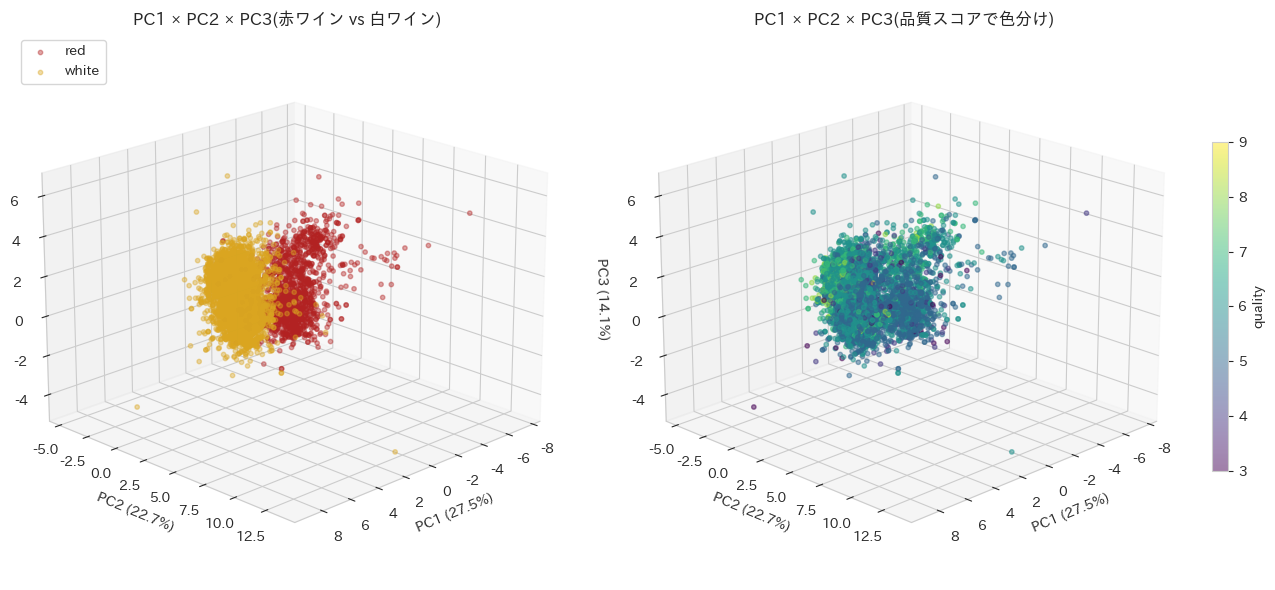

In [127]:
# PC1 × PC2 × PC3 の3次元空間でサンプルを可視化(色ラベルと品質スコアで色分け)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  -- '3d' projection を登録

pc_df = pd.DataFrame(scores[:, :3], columns=["PC1", "PC2", "PC3"])
pc_df["color"] = df["color"].values
pc_df["quality"] = df["quality"].values

fig = plt.figure(figsize=(14, 6))

# (左) 赤白の色ラベルで塗り分け
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
for c_label, c_hex in [("red", "#b22222"), ("white", "#daa520")]:
    mask = pc_df["color"] == c_label
    ax0.scatter(
        pc_df.loc[mask, "PC1"], pc_df.loc[mask, "PC2"], pc_df.loc[mask, "PC3"],
        c=c_hex, label=c_label, alpha=0.4, s=10,
    )
ax0.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax0.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax0.set_zlabel(f"PC3 ({explained[2]*100:.1f}%)")
ax0.set_title("PC1 × PC2 × PC3(赤ワイン vs 白ワイン)")
ax0.legend(loc="upper left")
ax0.view_init(elev=20, azim=45)

# (右) 品質スコアで連続的に色分け
ax1 = fig.add_subplot(1, 2, 2, projection="3d")
sc = ax1.scatter(
    pc_df["PC1"], pc_df["PC2"], pc_df["PC3"],
    c=pc_df["quality"], cmap="viridis", alpha=0.5, s=10,
)
ax1.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax1.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax1.set_zlabel(f"PC3 ({explained[2]*100:.1f}%)")
ax1.set_title("PC1 × PC2 × PC3(品質スコアで色分け)")
ax1.view_init(elev=20, azim=45)
fig.colorbar(sc, ax=ax1, shrink=0.6, label="quality")

plt.tight_layout()
plt.show()

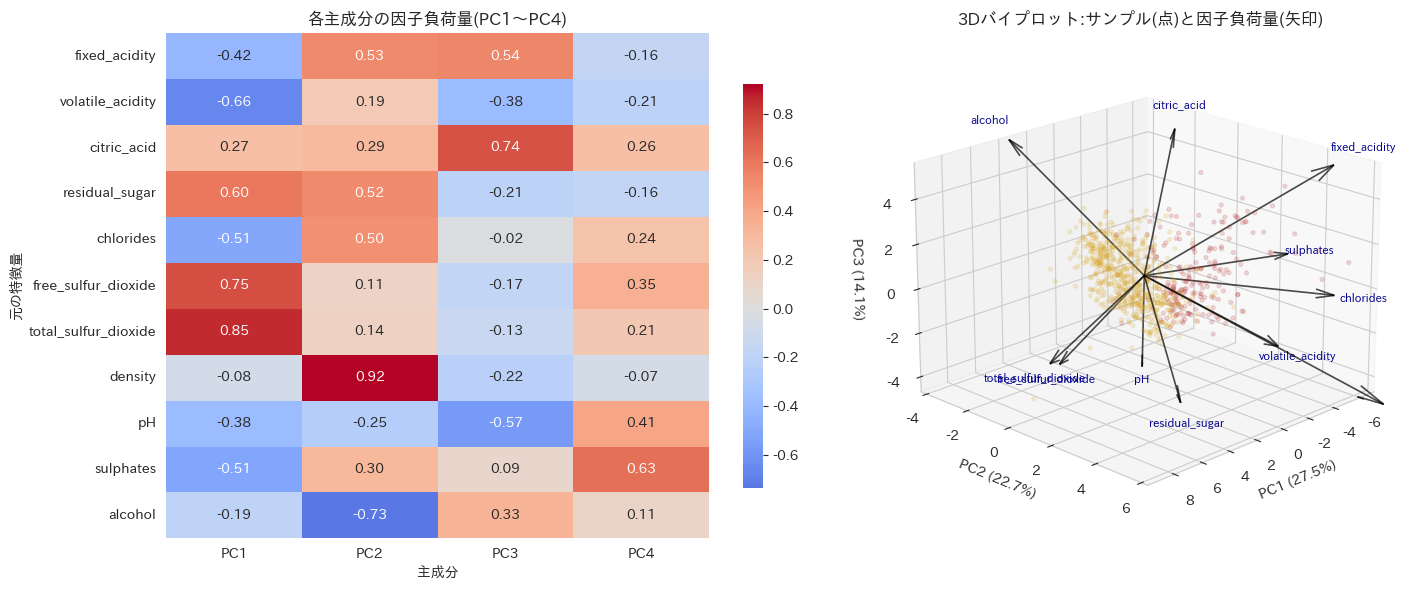

PC1 で絶対値が大きい変数 (≒ PC1 を主に作っている変数):
total_sulfur_dioxide    0.848490
free_sulfur_dioxide     0.750129
volatile_acidity        0.662817
residual_sugar          0.602172
sulphates               0.512026
Name: PC1, dtype: float64

PC2 で絶対値が大きい変数:
density           0.922374
alcohol           0.734469
fixed_acidity     0.531207
residual_sugar    0.521036
chlorides         0.497889
Name: PC2, dtype: float64

PC3 で絶対値が大きい変数:
citric_acid         0.736814
pH                  0.568077
fixed_acidity       0.541848
volatile_acidity    0.383347
alcohol             0.325757
Name: PC3, dtype: float64


In [128]:
# 因子負荷量(loadings)= 各主成分が元の変数とどれくらい相関しているか
# loadings_ij = components_ij * sqrt(eigenvalue_i)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(
    loadings[:, :4],
    index=features,
    columns=[f"PC{i+1}" for i in range(4)],
)

fig = plt.figure(figsize=(15, 6))

# (1) PC1〜PC4 の因子負荷量をヒートマップで
ax0 = fig.add_subplot(1, 2, 1)
sns.heatmap(
    loadings_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    cbar_kws={"shrink": 0.8}, ax=ax0,
)
ax0.set_title("各主成分の因子負荷量(PC1〜PC4)")
ax0.set_xlabel("主成分")
ax0.set_ylabel("元の特徴量")

# (2) PC1 × PC2 × PC3 の3Dバイプロット(矢印=変数の負荷量ベクトル)
ax1 = fig.add_subplot(1, 2, 2, projection="3d")
sample_idx = np.random.RandomState(42).choice(len(scores), size=800, replace=False)
ax1.scatter(
    scores[sample_idx, 0], scores[sample_idx, 1], scores[sample_idx, 2],
    c=["#b22222" if c == "red" else "#daa520" for c in df["color"].iloc[sample_idx]],
    alpha=0.15, s=8,
)

# 矢印スケール:散布図の範囲に合わせる
arrow_scale = np.abs(scores[:, :3]).max() * 0.8
for i, feat in enumerate(features):
    x = loadings[i, 0] * arrow_scale
    y = loadings[i, 1] * arrow_scale
    z = loadings[i, 2] * arrow_scale
    ax1.quiver(
        0, 0, 0, x, y, z,
        color="black", alpha=0.7, arrow_length_ratio=0.1, linewidth=1.2,
    )
    ax1.text(x * 1.15, y * 1.15, z * 1.15, feat,
             color="darkblue", fontsize=8, ha="center", va="center")

ax1.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
ax1.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
ax1.set_zlabel(f"PC3 ({explained[2]*100:.1f}%)")
ax1.set_title("3Dバイプロット:サンプル(点)と因子負荷量(矢印)")
ax1.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

print("PC1 で絶対値が大きい変数 (≒ PC1 を主に作っている変数):")
print(loadings_df["PC1"].abs().sort_values(ascending=False).head(5))
print("\nPC2 で絶対値が大きい変数:")
print(loadings_df["PC2"].abs().sort_values(ascending=False).head(5))
print("\nPC3 で絶対値が大きい変数:")
print(loadings_df["PC3"].abs().sort_values(ascending=False).head(5))

**学生への質問**
- PC1〜PC3 だけで全体の何%の分散を説明できていますか? 残りの主成分は捨ててしまって良いと言えるでしょうか?
- 3D 散布図で、赤ワインと白ワインはどの軸方向に分かれていますか? 第7章の階層的クラスタリングの結果と整合していますか?
- 3D バイプロットを別角度から見たい場合は、コード末尾の `ax1.view_init(elev=20, azim=45)` の数値を変えて再実行してみましょう。例えば `azim=120` にすると、別の変数の組が手前に来ます。
- バイプロットの矢印を見ると、`total_sulfur_dioxide` と `volatile_acidity` は逆方向を向いています。これは何を意味しますか?(ヒント:相関行列を思い出そう)
- PC2 や PC3 と品質スコアには関係がありそうですか? なければ、品質に効く軸は PC 何番目あたりに現れているか、因子負荷量から考察してみましょう。

## 9. 実習のまとめとディスカッション課題

1. **回帰タスクと分類タスクの違い**
   - 品質スコア(0〜10)は連続値ではなく整数だが、なぜポアソン回帰を使う?
   - 通常の線形回帰(正規分布)を使うとどう変わる?(`family=sm.families.Gaussian()` で試してみよう)

2. **モデルの解釈性 vs 精度**
   - GLM は係数で「どの変数がどれくらい効くか」がわかるが、精度では XGBoost に劣ることが多い。実務ではどちらを選ぶ?
   - 「ワインの品質を上げたい醸造家」と「品質を当てる予測モデルがほしいバイヤー」では選ぶモデルが違うかもしれない。

3. **多重共線性**
   - 相関行列で `density` が `alcohol` や `residual_sugar` と強く相関していた。これが GLM の係数推定にどう影響する?
   - XGBoost のような決定木ベースのアンサンブルは多重共線性に強いと言われる。なぜ?

4. **クラスタリングの解釈**
   - 赤白の区別は化学的に明らかなので、クラスタリングがうまくいった。では、品質スコアでクラスタリングしたらきれいに分かれる?(試してみよう)
   - クラスタ数を 3 や 4 にしたら、どんな解釈ができる?

## 発展課題

- **二値分類**: 品質 ≥ 7 を「良いワイン」とラベル付けし、ロジスティック回帰で予測してみる
- **赤白別の解析**: 赤ワインと白ワインで「品質に効く変数」が違うかを別々に GLM で確認する
- **ハイパーパラメータ調整**: XGBoost の `n_estimators`, `max_depth`, `learning_rate` を変えて精度の変化を確認する
